<a href="https://colab.research.google.com/github/pattichis/MLSP2026/blob/main/3D_Transformer_Fast_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Build and Train a 3D Transformer, Fast

We build a **3D Vision Transformer (ViT-3D)** from scratch in about 60 lines of PyTorch and train it in a few minutes on a Colab GPU (**Runtime → Change runtime type → T4 GPU**).

"3D" means the input has three axes: **time × height × width** for video, or **depth × height × width** for CT/MRI volumes. The architecture is the same for both:

| Step | Image ViT (2D) | ViT-3D |
|---|---|---|
| Input | (C, H, W) | (C, **T**, H, W) |
| Patches | 16 × 16 pixel squares | **2 × 8 × 8 cubes** ("tubelets"), made with a `Conv3d` |
| Position embedding | one per 2D patch | one per 3D patch (where **and** when) |
| Encoder | Transformer blocks | the **same** Transformer blocks |

**The task.** Synthetic videos of an MNIST digit moving in one of **8 directions**. Every single frame looks the same across classes (just a digit), so the model can only succeed by comparing frames over time. After training, we test that it really uses time.

| Section | Content |
|---|---|
| 1 | Synthetic video data, generated on the GPU |
| 2 | The ViT-3D architecture, built from scratch |
| 3 | Fast training (mixed precision, fused attention, one-cycle learning rate) |
| 4 | Does it use time? Reverse and shuffle the frames |
| 5 | Same model on real 3D medical volumes (OrganMNIST3D) |

## 1. Data: moving digits, generated on the GPU

Each video is 16 frames of 32 × 32 pixels. A 12 × 12 MNIST digit moves 1 pixel per frame in one of 8 directions. Videos are generated **on the fly on the GPU** in one vectorized call: training sees fresh data every step, there is no data loader, and the model cannot overfit to a fixed dataset. You don't need to read the generator in detail.

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 490kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.49MB/s]


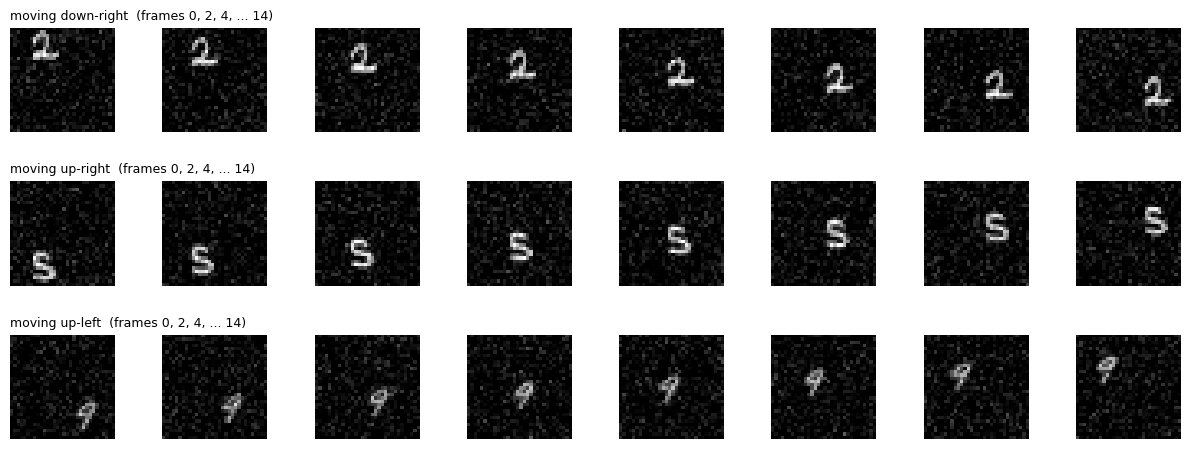

Batch shape: (3, 1, 16, 32, 32)  (batch, channels, time, height, width)


In [ ]:
import time, math, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)

T, S, D = 16, 32, 12          # frames, canvas size, digit size
def load_digits(train):
    x = datasets.MNIST("data", train=train, download=True).data[:, None].float() / 255
    return F.interpolate(x, size=D, mode="bilinear", antialias=True)[:, 0].to(device)
train_digits, test_digits = load_digits(True), load_digits(False)   # different digits for testing

#                    (dy, dx) per frame
DIRS = torch.tensor([(0, 1), (0, -1), (1, 0), (-1, 0), (1, 1), (1, -1), (-1, 1), (-1, -1)], device=device)
NAMES = ["right", "left", "down", "up", "down-right", "down-left", "up-right", "up-left"]
OPPOSITE = torch.tensor([(DIRS == -d).all(1).nonzero().item() for d in DIRS], device=device)

def make_batch(B, digits=train_digits, noise=0.1):
    """Return videos (B, 1, T, S, S) and direction labels (B,)."""
    dig = digits[torch.randint(len(digits), (B,), device=device)]
    y = torch.randint(8, (B,), device=device)
    d = DIRS[y]                                                     # (B, 2)
    room, travel = S - D, T - 1
    lo = torch.where(d < 0, travel, 0)                              # keep the digit on the canvas
    hi = torch.where(d > 0, room - travel, room)
    start = lo + (torch.rand(B, 2, device=device) * (hi - lo + 1)).long()
    pos = start[:, None] + torch.arange(T, device=device)[None, :, None] * d[:, None]   # (B, T, 2)
    grid = torch.arange(S, device=device)
    ry, rx = grid - pos[..., :1], grid - pos[..., 1:]               # (B, T, S) digit coordinates
    inside = ((ry >= 0) & (ry < D))[..., :, None] & ((rx >= 0) & (rx < D))[..., None, :]
    b = torch.arange(B, device=device)[:, None, None, None]
    video = dig[b, ry.clamp(0, D - 1)[..., :, None], rx.clamp(0, D - 1)[..., None, :]] * inside
    video = (video + noise * torch.randn_like(video)).clamp(0, 1)
    return video[:, None], y

v, y = make_batch(3)
fig, ax = plt.subplots(3, 8, figsize=(12, 4.8))
for r in range(3):
    for c in range(8):
        ax[r, c].imshow(v[r, 0, 2 * c].cpu(), cmap="gray", vmin=0, vmax=1); ax[r, c].axis("off")
    ax[r, 0].set_title(f"moving {NAMES[y[r]]}  (frames 0, 2, 4, ... 14)", fontsize=9, loc="left")
plt.tight_layout(); plt.show()
print("Batch shape:", tuple(v.shape), " (batch, channels, time, height, width)")

## 2. The ViT-3D architecture

Four small modules:

1. **`TubeletEmbed`**: a `Conv3d` whose kernel size equals its stride cuts the video into non-overlapping 2 × 8 × 8 cubes and projects each one to a `dim`-dimensional token. 16 × 32 × 32 → (16/2) × (32/8) × (32/8) = 8 × 4 × 4 = **128 tokens**.
2. **`Attention`**: multi-head self-attention. `F.scaled_dot_product_attention` automatically uses a fused FlashAttention-style kernel on GPU, which is much faster and uses less memory than computing the attention matrix by hand.
3. **`Block`**: a standard pre-norm Transformer block (attention + MLP, each with a residual connection).
4. **`ViT3D`**: adds a learnable `[CLS]` token and a learned position embedding for each 3D patch, runs the blocks, and classifies from the `[CLS]` token.

Nothing inside the Transformer blocks knows about 3D. All of the "3D-ness" lives in the tubelet embedding and the position embedding.

In [ ]:
class TubeletEmbed(nn.Module):
    def __init__(self, in_ch, dim, tubelet):
        super().__init__()
        self.proj = nn.Conv3d(in_ch, dim, kernel_size=tubelet, stride=tubelet)
    def forward(self, x):                        # (B, C, T, H, W)
        x = self.proj(x)                         # (B, dim, T', H', W')
        return x.flatten(2).transpose(1, 2)      # (B, N = T'H'W', dim)

class Attention(nn.Module):
    def __init__(self, dim, heads):
        super().__init__()
        self.heads = heads
        self.qkv = nn.Linear(dim, 3 * dim)
        self.proj = nn.Linear(dim, dim)
    def forward(self, x):
        B, N, C = x.shape
        q, k, v = self.qkv(x).reshape(B, N, 3, self.heads, C // self.heads).permute(2, 0, 3, 1, 4)
        x = F.scaled_dot_product_attention(q, k, v)          # fused kernel on GPU
        return self.proj(x.transpose(1, 2).reshape(B, N, C))

class Block(nn.Module):
    def __init__(self, dim, heads, mlp_ratio=4):
        super().__init__()
        self.norm1, self.attn = nn.LayerNorm(dim), Attention(dim, heads)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(nn.Linear(dim, mlp_ratio * dim), nn.GELU(), nn.Linear(mlp_ratio * dim, dim))
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        return x + self.mlp(self.norm2(x))

class ViT3D(nn.Module):
    def __init__(self, input_size=(16, 32, 32), in_ch=1, tubelet=(2, 8, 8),
                 dim=128, depth=4, heads=4, num_classes=8):
        super().__init__()
        self.embed = TubeletEmbed(in_ch, dim, tubelet)
        n_tokens = math.prod(s // p for s, p in zip(input_size, tubelet))
        self.cls = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos = nn.Parameter(torch.randn(1, n_tokens + 1, dim) * 0.02)
        self.blocks = nn.Sequential(*[Block(dim, heads) for _ in range(depth)])
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, num_classes)
    def forward(self, x):
        x = self.embed(x)
        x = torch.cat([self.cls.expand(len(x), -1, -1), x], dim=1) + self.pos
        x = self.norm(self.blocks(x))
        return self.head(x[:, 0])                # classify from the [CLS] token

model = ViT3D().to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.2f} M")
print("Tokens:", tuple(model.embed(v).shape), " (batch, tokens, dim)  + 1 [CLS] token")
print("Output:", tuple(model(v).shape), " (batch, classes)")

Parameters: 0.83 M
Tokens: (3, 128, 128)  (batch, tokens, dim)  + 1 [CLS] token
Output: (3, 8)  (batch, classes)


## 3. Fast training

What makes this fast:

| Trick | Why it helps |
|---|---|
| **Mixed precision** (`autocast` float16 + `GradScaler`) | Uses the GPU's tensor cores; roughly 2× faster, half the memory |
| **Fused attention** (`scaled_dot_product_attention`) | Never stores the full N × N attention matrix |
| **Large 3D patches** | 2 × 8 × 8 tubelets give only 128 tokens; attention cost grows with tokens² |
| **Data generated on the GPU** | No data-loading bottleneck; fresh samples every step |
| **One-cycle learning rate + AdamW** | Short warmup, then decay; converges in few steps |

This takes about 1 minute on a T4 GPU; training accuracy passes 95% within about 300 steps. On CPU it is several times slower; reduce `STEPS` to 400 if needed.

/tmp/ipykernel_3562/3963446954.py:20: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scaler.step(opt); scaler.update(); sched.step()


step   100   loss 1.442   train acc  41.1%     3.3 s
step   200   loss 0.106   train acc  96.6%     5.9 s
step   300   loss 0.030   train acc  99.0%     8.5 s
step   400   loss 0.025   train acc  99.2%    11.1 s
step   500   loss 0.005   train acc  99.9%    13.6 s
step   600   loss 0.003   train acc  99.9%    16.2 s
step   700   loss 0.002   train acc 100.0%    18.8 s
step   800   loss 0.001   train acc 100.0%    21.4 s


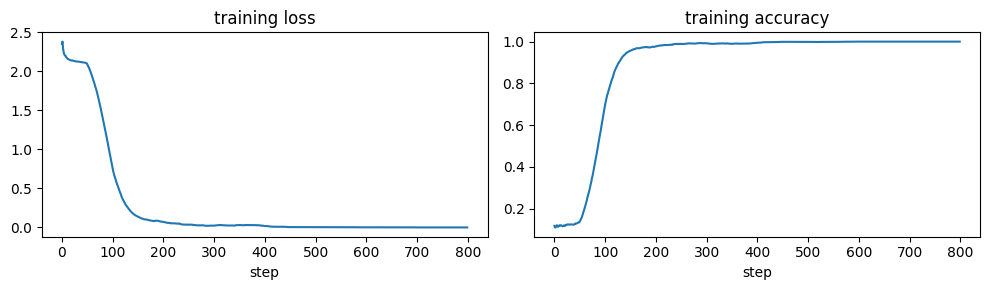

In [ ]:
STEPS, BATCH, LR = 800, 128, 1e-3
use_amp = device == "cuda"

model = ViT3D().to(device)
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=LR, total_steps=STEPS, pct_start=0.1)
scaler = torch.amp.GradScaler(enabled=use_amp)

history, t0 = [], time.time()
model.train()
for step in range(1, STEPS + 1):
    x, y = make_batch(BATCH)
    with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_amp):
        logits = model(x)
        loss = F.cross_entropy(logits, y)
    opt.zero_grad(set_to_none=True)
    scaler.scale(loss).backward()
    scaler.unscale_(opt)
    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    scaler.step(opt); scaler.update(); sched.step()

    history.append((loss.item(), (logits.argmax(1) == y).float().mean().item()))
    if step % 100 == 0:
        l, a = map(lambda z: sum(z) / len(z), zip(*history[-100:]))
        print(f"step {step:5d}   loss {l:.3f}   train acc {a:6.1%}   {time.time() - t0:5.1f} s")

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
smooth = lambda z: [sum(z[max(0, i - 49):i + 1]) / len(z[max(0, i - 49):i + 1]) for i in range(len(z))]
ax[0].plot(smooth([h[0] for h in history])); ax[0].set_title("training loss"); ax[0].set_xlabel("step")
ax[1].plot(smooth([h[1] for h in history])); ax[1].set_title("training accuracy"); ax[1].set_xlabel("step")
plt.tight_layout(); plt.show()

## 4. Test: does the model really use time?

We test on **unseen digits** (from the MNIST test set) and then change only the *order* of the frames:

- **Reversed:** the same frames played backward. A model that understands motion should predict the **opposite** direction.
- **Shuffled:** random frame order, so there is no consistent motion.
- **One frame repeated:** no motion at all. Also chance.

In [ ]:
@torch.no_grad()
def evaluate(transform, n=4000):
    model.eval()
    x, y = make_batch(n, test_digits)
    with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_amp):
        pred = model(transform(x)).argmax(1)
    return (pred == y).float().mean().item(), (pred == OPPOSITE[y]).float().mean().item()

tests = {
    "original":            lambda x: x,
    "reversed":            lambda x: x.flip(2),
    "shuffled":            lambda x: x[:, :, torch.randperm(T, device=device)],
    "one frame repeated":  lambda x: x[:, :, T // 2 : T // 2 + 1].expand_as(x),
}
print(f"{'test videos':22s}{'correct':>10s}{'predicted opposite':>22s}")
for name, fn in tests.items():
    acc, opp = evaluate(fn)
    print(f"{name:22s}{acc:10.1%}{opp:22.1%}")

test videos              correct    predicted opposite
original                  100.0%                  0.0%
reversed                    0.0%                100.0%
shuffled                   31.2%                 18.6%
one frame repeated         14.4%                 12.2%


Expected (from a test run): about 100% on the original videos. On **reversed** videos, accuracy drops to about 0% and nearly every prediction flips to the **opposite** direction: the model has learned motion, not appearance. With **one frame repeated**, accuracy falls to chance (12.5%).

**Shuffled** videos are the interesting case: accuracy stays above chance (25–40% in our test runs; it varies from run to run). Shuffling destroys the direction of motion, but the digit still appears at every position along its *path*. The model can still tell which line it moves along (horizontal, vertical, or one of the diagonals), but not which way, so it lands between chance (12.5%) and a coin flip within the correct line (50%).

Try:
- Change `tubelet=(2, 8, 8)` to `(1, 8, 8)` (twice the tokens: slower, maybe more accurate) or `(4, 8, 8)` (half the tokens: faster).
- Change `depth`, `dim`, or `heads` in `ViT3D(...)`.
- Turn off mixed precision (`use_amp = False`) and compare the training time.

## 5. The same model on real 3D volumes: OrganMNIST3D

For CT or MRI, the third axis is **depth** instead of time. Only the constructor arguments change. **OrganMNIST3D** (from MedMNIST) contains 28 × 28 × 28 abdominal CT volumes labeled with one of 11 organs (about 1,000 training volumes).

With 4 × 4 × 4 patches, a 28³ volume becomes 7 × 7 × 7 = 343 tokens. Because the training set is small, we add simple augmentation (random flips). Training takes about 1–2 minutes on a T4 GPU.

In [ ]:
!pip install -q medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.6 MB/s eta 0:00:00


100%|██████████| 32.7M/32.7M [00:32<00:00, 996kB/s] 


train: (971, 1, 28, 28, 28)  test: (610, 1, 28, 28, 28)  classes: 11


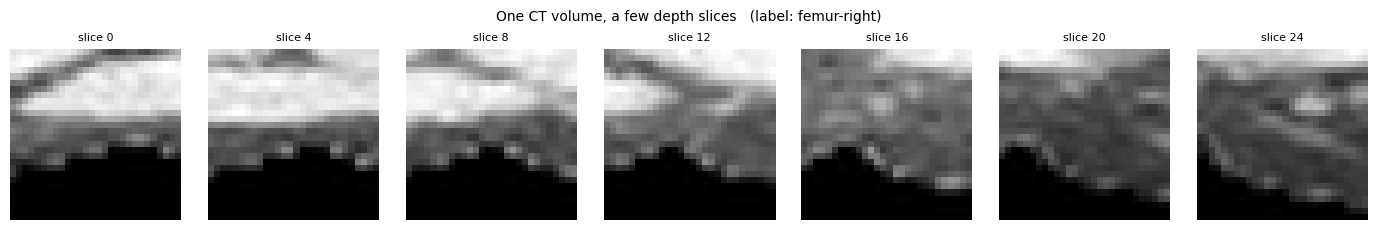

In [ ]:
import numpy as np
from medmnist import OrganMNIST3D

def to_tensors(split):
    ds = OrganMNIST3D(split=split, download=True, size=28)
    x = torch.tensor(ds.imgs, dtype=torch.float32)[:, None] / 255      # (N, 1, 28, 28, 28)
    y = torch.tensor(ds.labels[:, 0], dtype=torch.long)
    return x.to(device), y.to(device)
xtr, ytr = to_tensors("train")
xte, yte = to_tensors("test")
organs = list(OrganMNIST3D(split="test", download=True, size=28).info["label"].values())
print("train:", tuple(xtr.shape), " test:", tuple(xte.shape), " classes:", len(organs))

fig, ax = plt.subplots(1, 7, figsize=(14, 2.3))
for i, a in enumerate(ax):
    a.imshow(xtr[0, 0, 4 * i].cpu(), cmap="gray"); a.set_title(f"slice {4 * i}", fontsize=8); a.axis("off")
fig.suptitle(f"One CT volume, a few depth slices   (label: {organs[ytr[0]]})", fontsize=10)
plt.tight_layout(); plt.show()

In [ ]:
vol_model = ViT3D(input_size=(28, 28, 28), tubelet=(4, 4, 4), dim=128, depth=4, heads=4,
                  num_classes=len(organs)).to(device)
EPOCHS, BATCH, LR = 40, 64, 1e-3
steps = EPOCHS * math.ceil(len(xtr) / BATCH)
opt = torch.optim.AdamW(vol_model.parameters(), lr=LR, weight_decay=0.05)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=LR, total_steps=steps, pct_start=0.1)
scaler = torch.amp.GradScaler(enabled=use_amp)

def augment(x):
    for dim in (2, 3, 4):                    # random flip along each axis, per sample
        flip = torch.rand(len(x), device=device) < 0.5
        x = torch.where(flip[:, None, None, None, None], x.flip(dim), x)
    return x

@torch.no_grad()
def vol_accuracy(x, y):
    vol_model.eval()
    with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_amp):
        pred = torch.cat([vol_model(x[i:i + 256]).argmax(1) for i in range(0, len(x), 256)])
    return (pred == y).float().mean().item()

t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    vol_model.train()
    for idx in torch.randperm(len(xtr), device=device).split(BATCH):
        with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_amp):
            loss = F.cross_entropy(vol_model(augment(xtr[idx])), ytr[idx], label_smoothing=0.1)
        opt.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.step(opt); scaler.update(); sched.step()
    if epoch % 10 == 0:
        print(f"epoch {epoch:3d}   loss {loss.item():.3f}   test acc {vol_accuracy(xte, yte):6.1%}   {time.time() - t0:5.1f} s")

epoch  10   loss 1.194   test acc  48.9%     5.6 s
epoch  20   loss 0.790   test acc  64.4%    11.8 s
epoch  30   loss 1.124   test acc  67.9%    17.4 s
epoch  40   loss 0.771   test acc  69.7%    22.7 s


Expect roughly 65–70% test accuracy (69% in our run). A ViT trained from scratch on only about 1,000 volumes is data-limited. For reference, the MedMNIST paper reports roughly 90% test accuracy for 3D ResNets on this dataset. To close the gap: use more augmentation, pretrain with masked autoencoding (as VideoMAE does), or use a hybrid CNN + Transformer model.

## Key ideas

| Concept | Meaning |
|---|---|
| Tubelet / 3D patch | A `Conv3d` with kernel = stride turns a volume into a sequence of tokens |
| 3D position embedding | Tells the model *where and when* each token came from; without it, attention cannot see order |
| Token count | (T/pt) × (H/ph) × (W/pw); attention cost grows with its square, so patch size is the main speed knob |
| Same encoder | Transformer blocks are identical for text, images, video, and volumes |
| Fast training | Mixed precision + fused attention + few tokens + on-GPU data |

## Next steps

- **Factorized attention** (TimeSformer, ViViT): attend over space and time separately, to handle many more tokens.
- **Masked pretraining** (VideoMAE): pretrain without labels, then fine-tune on small labeled datasets.
- **3D medical models**: UNETR and Swin UNETR (MONAI library) use this same encoder for 3D segmentation.